In [1]:
import numpy as np
import sympy as sp
import itertools
from wddegp.wddegp import wddegp
import utils
from matplotlib import pyplot as plt

plt.rcParams.update({'font.size': 12})

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 2
n_bases = 2
num_pts_per_axis = 5
domain_bounds = ((-1, 1), (-1, 1))
test_grid_resolution = 50
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 100
random_seed = 0
np.random.seed(random_seed)

In [3]:
# Submodel groups (initial grid indices before reordering)
submodel_groups_initial = [
    [1, 2, 3],                          # Submodel 0: Top edge
    [5, 10, 15],                        # Submodel 1: Left edge
    [9, 14, 19],                        # Submodel 2: Right edge
    [21, 22, 23],                       # Submodel 3: Bottom edge
    [0],                                # Submodel 4: Top-left corner
    [4],                                # Submodel 5: Top-right corner
    [20],                               # Submodel 6: Bottom-left corner
    [24],                               # Submodel 7: Bottom-right corner
    [6, 7, 8, 11, 12, 13, 16, 17, 18]  # Submodel 8: Interior points
]

# Ray angles per submodel (in radians)
submodel_ray_thetas = [
    [-np.pi/4, 0, np.pi/4],             # Submodel 0: Three rays (diagonal left, horizontal, diagonal right)
    [-np.pi/4, 0, np.pi/4],             # Submodel 1: Three rays
    [-np.pi/4, 0, np.pi/4],             # Submodel 2: Three rays
    [-np.pi/4, 0, np.pi/4],             # Submodel 3: Three rays
    [-np.pi/2, 0, -np.pi/4],            # Submodel 4: Vertical down, horizontal, diagonal
    [np.pi/2, 0, np.pi/4],              # Submodel 5: Vertical up, horizontal, diagonal
    [np.pi/2, 0, np.pi/4],              # Submodel 6: Vertical up, horizontal, diagonal
    [-np.pi/2, 0, -np.pi/4],            # Submodel 7: Vertical down, horizontal, diagonal
    [np.pi/2, np.pi/4, np.pi/4 + np.pi/2]  # Submodel 8: Interior rays
]

# Derivative indices specification (same for all submodels in this example)
submodel_der_indices = [
    [[[[1,1]], [[1,2]], [[2,1]], [[2,2]], [[3,1]], [[3,2]]]]
    for _ in range(len(submodel_groups_initial))
]

In [4]:
# Define symbolic variables
x1_sym, x2_sym = sp.symbols('x1 x2')

# Define symbolic Six-Hump Camel function
f_sym = ((4 - 2.1*x1_sym**2 + (x1_sym**4)/3.0) * x1_sym**2 +
         x1_sym*x2_sym + (-4 + 4*x2_sym**2) * x2_sym**2)

# Compute symbolic gradients
grad_x1_sym = sp.diff(f_sym, x1_sym)
grad_x2_sym = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
true_function_np = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1_sym, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2_sym, 'numpy')

def true_function(X):
    """Six-Hump Camel function."""
    return true_function_np(X[:, 0], X[:, 1])

def true_gradient(x1, x2):
    """Analytical gradient of the Six-Hump Camel function."""
    gx1 = grad_x1_func(x1, x2)
    gx2 = grad_x2_func(x1, x2)
    return gx1, gx2

In [5]:
def generate_training_data():
    """Generate WDDEGP training data with heterogeneous submodels using SymPy."""

    # 1. Create initial uniform grid (5×5 = 25 points)
    x_vals = np.linspace(domain_bounds[0][0], domain_bounds[0][1], num_pts_per_axis)
    y_vals = np.linspace(domain_bounds[1][0], domain_bounds[1][1], num_pts_per_axis)
    X_initial = np.array(list(itertools.product(x_vals, y_vals)))

    # 2. Reorder training points for contiguous submodel indices
    # WDDEGP requires that each submodel's indices are contiguous
    sequential_groups = []
    current_pos = 0
    for group in submodel_groups_initial:
        sequential_groups.append(list(range(current_pos, current_pos + len(group))))
        current_pos += len(group)

    # Create reordering map: old grid indices -> new sequential positions
    old_flat = list(itertools.chain.from_iterable(submodel_groups_initial))
    new_flat = list(itertools.chain.from_iterable(sequential_groups))
    reorder_map = np.zeros(len(old_flat), dtype=int)
    for i in range(len(old_flat)):
        reorder_map[new_flat[i]] = old_flat[i]

    X_train = X_initial[reorder_map]

    # 3. Generate per-submodel data using SymPy gradients
    y_train_data_all = []
    rays_data_all = []
    y_func_values = true_function(X_train).reshape(-1, 1)

    for k, group_indices in enumerate(sequential_groups):
        # Extract points for this submodel
        X_sub = X_train[group_indices]

        # Create rays for this submodel
        thetas = submodel_ray_thetas[k]
        rays = np.column_stack([[np.cos(t), np.sin(t)] for t in thetas])

        # Normalize rays to unit length
        for i in range(rays.shape[1]):
            rays[:, i] = rays[:, i] / np.linalg.norm(rays[:, i])

        rays_data_all.append(rays)

        # Compute directional derivatives using chain rule
        y_train_submodel = [y_func_values]  # All submodels share function values

        for ray_idx, ray in enumerate(rays.T):
            # Compute first and second order directional derivatives
            for order in range(1, n_order + 1):
                deriv_values = []

                for point in X_sub:
                    x1, x2 = point[0], point[1]

                    # Get gradient at this point
                    gx1, gx2 = true_gradient(x1, x2)

                    if order == 1:
                        # First-order directional derivative: ∇f · d
                        d_ray = gx1 * ray[0] + gx2 * ray[1]
                        deriv_values.append(d_ray)

                    elif order == 2:
                        # Second-order directional derivative: d^T H d
                        # Compute Hessian components symbolically
                        if not hasattr(generate_training_data, 'hessian_funcs'):
                            # Cache Hessian functions
                            h11 = sp.diff(grad_x1_sym, x1_sym)
                            h12 = sp.diff(grad_x1_sym, x2_sym)
                            h22 = sp.diff(grad_x2_sym, x2_sym)
                            generate_training_data.hessian_funcs = {
                                'h11': sp.lambdify([x1_sym, x2_sym], h11, 'numpy'),
                                'h12': sp.lambdify([x1_sym, x2_sym], h12, 'numpy'),
                                'h22': sp.lambdify([x1_sym, x2_sym], h22, 'numpy')
                            }

                        h11_val = generate_training_data.hessian_funcs['h11'](x1, x2)
                        h12_val = generate_training_data.hessian_funcs['h12'](x1, x2)
                        h22_val = generate_training_data.hessian_funcs['h22'](x1, x2)

                        # d^T H d = d1^2 * H11 + 2*d1*d2 * H12 + d2^2 * H22
                        d2_ray = (ray[0]**2 * h11_val +
                                 2 * ray[0] * ray[1] * h12_val +
                                 ray[1]**2 * h22_val)
                        deriv_values.append(d2_ray)

                y_train_submodel.append(np.array(deriv_values).reshape(-1, 1))

        y_train_data_all.append(y_train_submodel)

    return X_train, sequential_groups, y_train_data_all, rays_data_all

In [6]:
def train_model(X_train, submodel_indices, y_train_data_all, rays_data_all):
    """Initialize and train WDDEGP model with heterogeneous submodels."""

    gp_model = wddegp(
        X_train,
        y_train_data_all,
        n_order,
        n_bases,
        submodel_indices,
        submodel_der_indices,
        rays_data_all,
        normalize=normalize_data,
        kernel=kernel,
        kernel_type=kernel_type
    )

    params = gp_model.optimize_hyperparameters(
        optimizer='jade',
        pop_size=100,
        n_generations=15,
        local_opt_every=None,
        debug=True
    )

    return gp_model, params

In [7]:
def evaluate_model(gp_model, params, X_train):
    """Evaluate WDDEGP on a test grid."""

    # Create test grid
    x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
    y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
    X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

    # Make predictions (return_submodels=True gives individual submodel outputs)
    y_pred, _ = gp_model.predict(X_test, params,
                                  calc_cov=False,
                                  return_submodels=True)

    # Compute true function values
    y_true = true_function(X_test)

    # Calculate error metric
    nrmse_val = utils.nrmse(y_true, y_pred)

    return {'X_test': X_test,
            'X1_grid': X1_grid,
            'X2_grid': X2_grid,
            'y_pred': y_pred,
            'y_true': y_true,
            'nrmse': nrmse_val,
            'X_train': X_train}

In [8]:
def visualize_results(results):
    """Create 3-panel contour plot: prediction, truth, error."""

    X_train = results['X_train']
    y_true_grid = results['y_true'].reshape(results['X1_grid'].shape)
    y_pred_grid = results['y_pred'].reshape(results['X1_grid'].shape)
    abs_error_grid = np.abs(y_true_grid - y_pred_grid)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # WDDEGP Prediction
    c1 = axes[0].contourf(results['X1_grid'], results['X2_grid'],
                           y_pred_grid, levels=50, cmap="viridis")
    axes[0].scatter(X_train[:, 0], X_train[:, 1],
                    c="red", edgecolor="k", s=50, zorder=5)
    axes[0].set_title("WDDEGP Prediction")
    fig.colorbar(c1, ax=axes[0])

    # True Function
    c2 = axes[1].contourf(results['X1_grid'], results['X2_grid'],
                           y_true_grid, levels=50, cmap="viridis")
    axes[1].scatter(X_train[:, 0], X_train[:, 1],
                    c="red", edgecolor="k", s=50, zorder=5)
    axes[1].set_title("True Function")
    fig.colorbar(c2, ax=axes[1])

    # Absolute Error
    c3 = axes[2].contourf(results['X1_grid'], results['X2_grid'],
                           abs_error_grid, levels=50, cmap="magma")
    axes[2].scatter(X_train[:, 0], X_train[:, 1],
                    c="red", edgecolor="k", s=50, zorder=5)
    axes[2].set_title("Absolute Error")
    fig.colorbar(c3, ax=axes[2])

    for ax in axes:
        ax.set(xlabel="$x_1$", ylabel="$x_2$")
        ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()

Gen 1: best f=434.06575590997016


Gen 2: best f=434.06575590997016


Gen 3: best f=434.06575590997016


Gen 4: best f=421.7935115978095


Gen 5: best f=421.7935115978095


...

Gen 11: best f=157.93790507817033


Gen 12: best f=157.93790507817033


Gen 13: best f=157.93790507817033


Gen 14: best f=157.93790507817033


Gen 15: best f=62.771211579984495


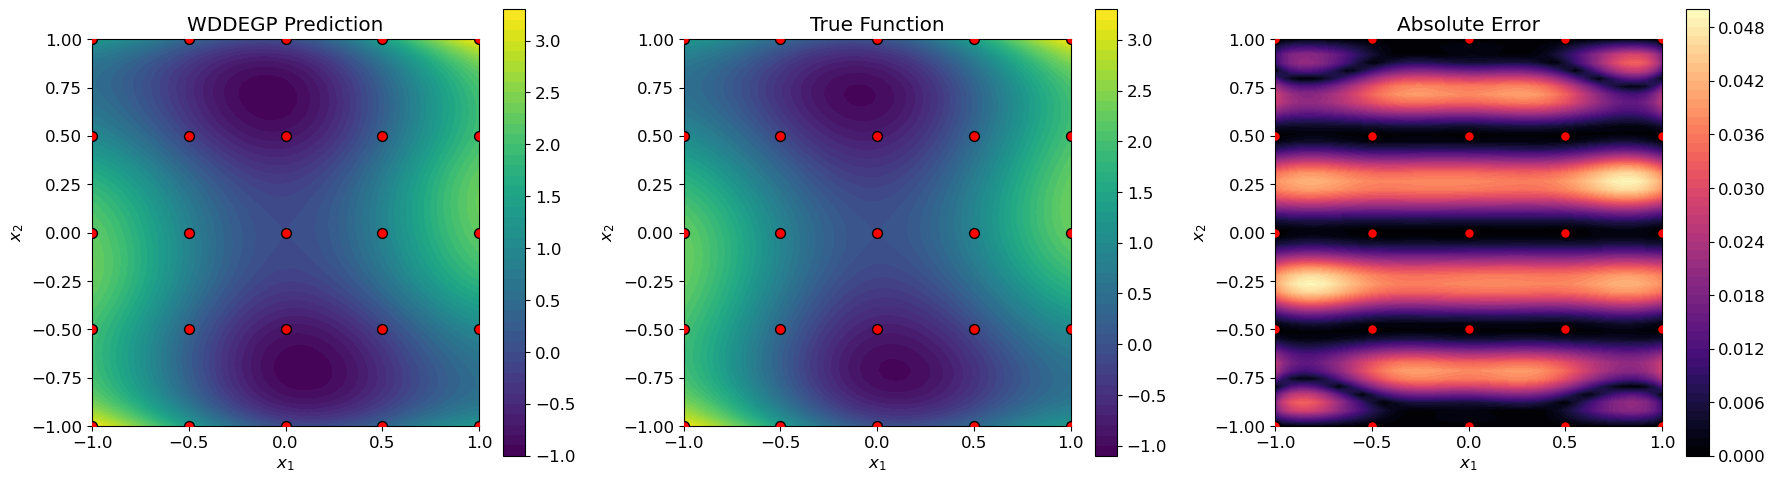

Final NRMSE: 0.005103


In [9]:
X_train, submodel_indices, y_train_data_all, rays_data_all = generate_training_data()
gp_model, params = train_model(X_train, submodel_indices, y_train_data_all, rays_data_all)
results = evaluate_model(gp_model, params, X_train)
visualize_results(results)
print(f"Final NRMSE: {results['nrmse']:.6f}")